Loading required package: nnet



Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Meta-train rows: 1600 
Meta-test rows : 400 

NA check meta_train:
 del_mean_emb_1  del_mean_emb_2  del_mean_emb_3  del_mean_emb_4  del_mean_emb_5 
              0               0               0               0               0 
 del_mean_emb_6  del_mean_emb_7  del_mean_emb_8  del_mean_emb_9 del_mean_emb_10 
              0               0               0               0               0 
del_mean_emb_11 del_mean_emb_12 del_mean_emb_13 del_mean_emb_14 del_mean_emb_15 
              0               0               0               0               0 
del_mean_emb_16   del_max_emb_1   del_max_emb_2   del_max_emb_3   del_max_emb_4 
              

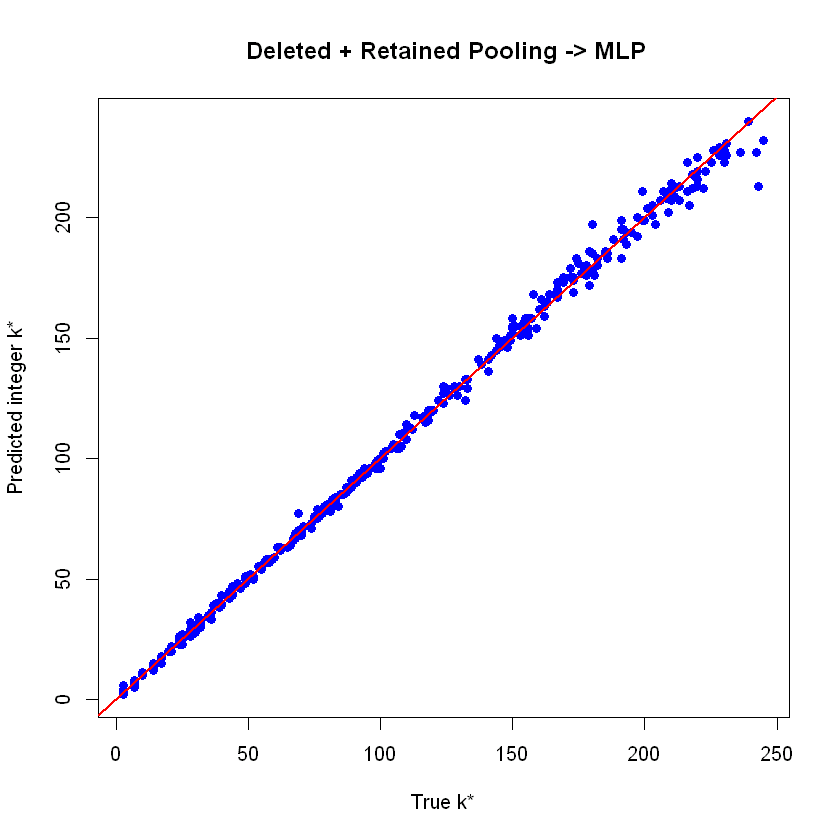

In [1]:
# ============================================================
# FULL R CODE
# Option 2:
# p_i -> K_i -> deleted set D_i + retained set R_i -> k*_i
# then:
# pooled deleted features + pooled retained features + p_i + K_i -> MLP -> k*
#
# Based on your safer second code
# ============================================================

set.seed(42)

# ----------------------------
# 0) Package
# ----------------------------
if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

# ----------------------------
# 1) Simulate linear Gaussian data
# ----------------------------
simulate_linear_gaussian <- function(n = 100,
                                     w_true = -5.0,
                                     b_true = 35.0,
                                     sigma = 1.5,
                                     seed = NULL) {
  if (!is.null(seed)) set.seed(seed)
  X <- runif(n, 1.5, 5.5)
  eps <- rnorm(n, 0, sigma)
  Y <- w_true * X + b_true + eps
  data.frame(x = X, y = Y)
}

# ----------------------------
# 2) Safe helpers
# ----------------------------
safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

safe_mean <- function(x) {
  if (length(x) == 0) return(0)
  m <- mean(x)
  if (is.na(m) || is.nan(m) || is.infinite(m)) return(0)
  m
}

# ----------------------------
# 3) Standardization for GD/GA
# ----------------------------
standardize_xy <- function(x, y, x_mean, x_sd, y_mean, y_sd) {
  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1
  xs <- (x - x_mean) / x_sd
  ys <- (y - y_mean) / y_sd
  list(X = xs, Y = ys)
}

# ----------------------------
# 4) Core optimization
# ----------------------------
grads <- function(X, Y, w, b) {
  r <- Y - (w * X + b)
  n <- length(X)
  dw <- (-2 / n) * sum(X * r)
  db <- (-2 / n) * sum(r)
  c(dw = dw, db = db)
}

step_gd <- function(X, Y, w, b, eta) {
  g <- grads(X, Y, w, b)
  c(w = as.numeric(w - eta * g["dw"]),
    b = as.numeric(b - eta * g["db"]))
}

step_ga <- function(X, Y, w, b, eta) {
  g <- grads(X, Y, w, b)
  c(w = as.numeric(w + eta * g["dw"]),
    b = as.numeric(b + eta * g["db"]))
}

fit_gd <- function(X, Y, iters = 800, eta = 0.10, w0 = 0, b0 = 0) {
  w <- as.numeric(w0)
  b <- as.numeric(b0)
  for (i in 1:iters) {
    p <- step_gd(X, Y, w, b, eta)
    w <- p["w"]
    b <- p["b"]
  }
  c(w = as.numeric(w), b = as.numeric(b))
}

# ----------------------------
# 5) One experiment
# Sample p_i in (0, 0.5], then compute K_i = floor(N * p_i)
# Return deleted set, retained set, p_i, K_i, k*_i
# ----------------------------
one_experiment_deleted_retained <- function(df,
                                            p_del,
                                            T_GD = 800,
                                            ETA_GD = 0.10,
                                            T_GA = 800,
                                            ETA_GA = 0.0015) {

  x <- df$x
  y <- df$y
  n <- nrow(df)

  # compute K from p
  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  x_mean <- mean(x); x_sd <- safe_sd(x)
  y_mean <- mean(y); y_sd <- safe_sd(y)

  st <- standardize_xy(x, y, x_mean, x_sd, y_mean, y_sd)
  X <- st$X
  Y <- st$Y

  # Full model
  full_fit <- fit_gd(X, Y, iters = T_GD, eta = ETA_GD)
  w_f <- full_fit["w"]
  b_f <- full_fit["b"]

  # Random deletion set
  del_idx <- sample(1:n, K_del, replace = FALSE)
  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  X_del <- X[del_mask]
  Y_del <- Y[del_mask]

  X_ret <- X[!del_mask]
  Y_ret <- Y[!del_mask]

  # Retained model
  ret_fit <- fit_gd(X_ret, Y_ret, iters = T_GD, eta = ETA_GD)
  w_r <- ret_fit["w"]
  b_r <- ret_fit["b"]

  # GA trajectory from full model on deleted set
  w_ga <- w_f
  b_ga <- b_f
  traj_w <- c(w_ga)
  traj_b <- c(b_ga)

  for (i in 1:T_GA) {
    p <- step_ga(X_del, Y_del, w_ga, b_ga, ETA_GA)
    w_ga <- p["w"]
    b_ga <- p["b"]
    traj_w <- c(traj_w, w_ga)
    traj_b <- c(traj_b, b_ga)
  }

  # true k*
  dists <- (traj_w - w_r)^2 + (traj_b - b_r)^2
  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del
  )
}

# ----------------------------
# 6) Build many experiments
# sample p_i ~ Uniform(p_min, p_max)
# ----------------------------
build_experiment_dataset <- function(df,
                                     n_experiments = 2000,
                                     p_min = 0.01,
                                     p_max = 0.50,
                                     T_GD = 800,
                                     ETA_GD = 0.10,
                                     T_GA = 800,
                                     ETA_GA = 0.0015) {

  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      T_GD = T_GD,
      ETA_GD = ETA_GD,
      T_GA = T_GA,
      ETA_GA = ETA_GA
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

# ----------------------------
# 7) Random shared embedding + pooling
# mean + max + min + sd
# ----------------------------
embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty set encountered.")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

# ----------------------------
# 8) Build pooled feature table
# Use BOTH deleted and retained pooled features
# ----------------------------
build_pooled_feature_table <- function(samples,
                                       embed_dim = 16,
                                       total_raw_n = 100,
                                       seed = 42) {
  set.seed(seed)

  # shared embedding parameters
  W <- matrix(rnorm(2 * embed_dim, mean = 0, sd = 0.3),
              nrow = 2, ncol = embed_dim)
  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_",  1:embed_dim),
      paste0("del_min_emb_",  1:embed_dim),
      paste0("del_sd_emb_",   1:embed_dim),

      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_",  1:embed_dim),
      paste0("ret_min_emb_",  1:embed_dim),
      paste0("ret_sd_emb_",   1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  out <- do.call(rbind, rows)
  out <- na.omit(out)

  out
}

# ----------------------------
# 9) Scale features
# ----------------------------
scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1
  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0
  scaled
}

# ----------------------------
# 10) Safer nnet fit with multiple random starts
# ----------------------------
fit_best_nnet <- function(x_train_sc,
                          y_train,
                          hidden_units = 8,
                          decay = 0.001,
                          maxit = 1000,
                          maxnwts = 15000,
                          n_repeats = 5,
                          seed = 42) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All nnet fits failed.")
  best_fit
}

# ----------------------------
# 11) Convert prediction to valid integer k*
# ----------------------------
postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(
    pred_raw = pred_raw,
    pred_int = pred_int
  )
}

# ----------------------------
# 12) CV for MLP regression
# ----------------------------
cv_mlp_regression <- function(meta_train,
                              k_folds = 5,
                              hidden_units = 8,
                              decay = 0.001,
                              maxit = 1000,
                              n_repeats = 5,
                              T_GA = 800,
                              seed = 42) {
  set.seed(seed)
  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    # scale y within fold
    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)
    if (y_sd_fold == 0) y_sd_fold <- 1
    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)
    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(scale_features_apply(x_valid, sc$means, sc$sds))

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      decay = decay,
      maxit = maxit,
      n_repeats = n_repeats,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))
    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    fold_rmse_raw = rmse_raw_vec,
    fold_rmse_int = rmse_int_vec,
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

# ----------------------------
# 13) Final train/test fit
# ----------------------------
train_and_test_mlp <- function(meta_train,
                               meta_test,
                               hidden_units = 8,
                               decay = 0.001,
                               maxit = 1000,
                               n_repeats = 5,
                               T_GA = 800,
                               seed = 42) {
  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)
  if (target_sd == 0) target_sd <- 1

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test  <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)
  x_train_sc <- as.matrix(sc$data)
  x_test_sc  <- as.matrix(scale_features_apply(x_test, sc$means, sc$sds))

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    decay = decay,
    maxit = maxit,
    n_repeats = n_repeats,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))
  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int  <- mean(abs(pred_out$pred_int - y_test))

  list(
    model = final_mlp,
    pred_raw = pred_out$pred_raw,
    pred_int = pred_out$pred_int,
    y_test = y_test,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# ----------------------------
# 14) MAIN
# ----------------------------
base_df <- simulate_linear_gaussian(n = 100, seed = 7)
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,   # start here, increase later if needed
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 800,
  ETA_GD = 0.10,
  T_GA = 800,
  ETA_GA = 0.0015
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = 100,
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

set.seed(42)
idx_meta_train <- sample(seq_len(nrow(meta_all)), size = floor(0.8 * nrow(meta_all)))
meta_train <- meta_all[idx_meta_train, ]
meta_test  <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

cat("NA check meta_train:\n")
print(colSums(is.na(meta_train)))
cat("\nNA check meta_test:\n")
print(colSums(is.na(meta_test)))
cat("\n")

# CV
cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  k_folds = 5,
  hidden_units = 8,
  decay = 0.001,
  maxit = 1000,
  n_repeats = 5,
  T_GA = 800,
  seed = 42
)

cat("CV fold RMSE (raw):\n")
print(cv_res$fold_rmse_raw)
cat("CV fold RMSE (integer):\n")
print(cv_res$fold_rmse_int)
cat(sprintf("Mean CV RMSE raw: %.4f\n", cv_res$mean_rmse_raw))
cat(sprintf("Mean CV RMSE int: %.4f\n\n", cv_res$mean_rmse_int))

# Final train/test
final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 8,
  decay = 0.001,
  maxit = 1000,
  n_repeats = 5,
  T_GA = 800,
  seed = 42
)

cat(sprintf("Final Test RMSE raw: %.4f\n", final_res$rmse_raw))
cat(sprintf("Final Test RMSE int: %.4f\n", final_res$rmse_int))
cat(sprintf("Final Test MAE int : %.4f\n\n", final_res$mae_int))

# Plot predictions
plot(final_res$y_test, final_res$pred_int,
     pch = 16, col = "blue",
     xlab = "True k*",
     ylab = "Predicted integer k*",
     main = " Deleted + Retained Pooling -> MLP")
abline(0, 1, col = "red", lwd = 2)

Noise version: Gaussian N(0, yi)
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Meta-train rows: 1600 
Meta-test rows : 400 

NA check meta_train:
 del_mean_emb_1  del_mean_emb_2  del_mean_emb_3  del_mean_emb_4  del_mean_emb_5 
              0               0               0               0               0 
 del_mean_emb_6  del_mean_emb_7  del_mean_emb_8  del_mean_emb_9 del_mean_emb_10 
              0               0               0               0               0 
del_mean_emb_11 del_mean_emb_12 del_mean_emb_13 del_mean_emb_14 del_mean_emb_15 
              0               0               0               0               0 
del_mean_emb_16   del_max_emb_1   del_max_emb_2   del_max_emb_

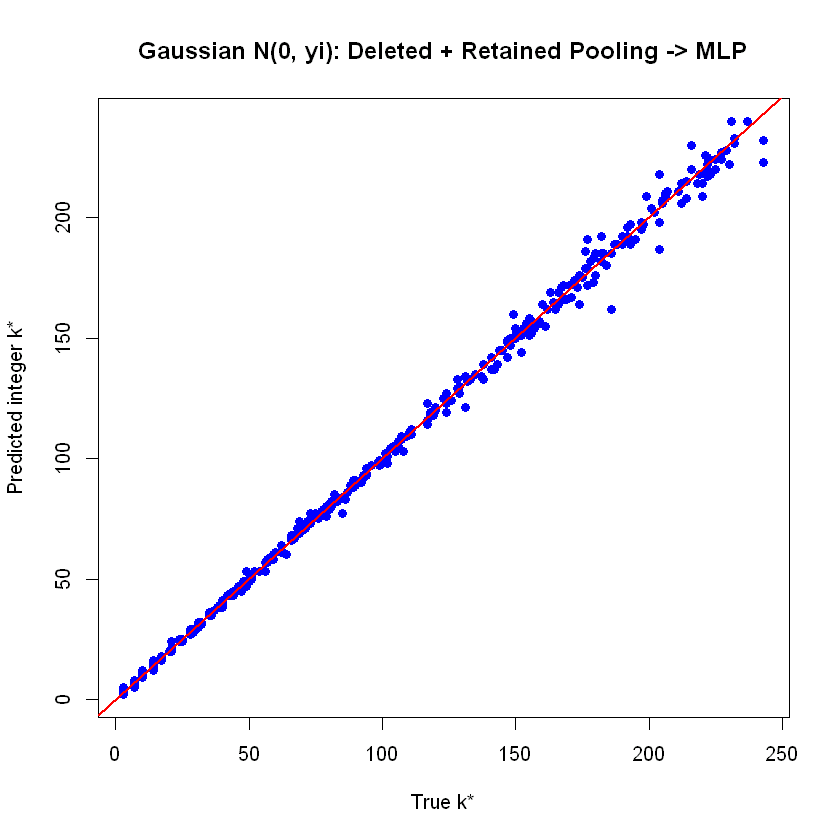

In [3]:
# ============================================================
# FULL R CODE
# Version 1: Linear model with heteroscedastic Gaussian noise
#
# Noise setting:
#   y_true = w*x + b
#   observed y = y_true + e
#   e_i ~ N(0, y_i)
#
# Implemented safely as:
#   e_i ~ N(0, sqrt(abs(y_true_i)))
#
# Pipeline:
#   random deletion experiments
#   deleted + retained sets
#   compute true k*
#   embedding + mean/max/min/sd pooling
#   MLP predicts k*
# ============================================================

set.seed(42)

# ----------------------------
# 0) Package
# ----------------------------
if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

# ----------------------------
# 1) Simulate linear data with N(0, yi) noise
# ----------------------------
simulate_linear_gaussian_yi <- function(n = 100,
                                        w_true = -5.0,
                                        b_true = 35.0,
                                        x_min = 1.5,
                                        x_max = 5.5,
                                        min_sd = 0.001,
                                        seed = NULL) {
  if (!is.null(seed)) set.seed(seed)

  X <- runif(n, x_min, x_max)

  # true noiseless output
  y_true <- w_true * X + b_true

  # e_i ~ N(0, y_i)
  # In R, sd must be positive, so use sqrt(abs(y_true))
  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(n, mean = 0, sd = sigma_i)

  Y <- y_true + eps

  data.frame(x = X, y = Y, y_true = y_true, sigma_i = sigma_i)
}

# ----------------------------
# 2) Safe helpers
# ----------------------------
safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

safe_mean <- function(x) {
  if (length(x) == 0) return(0)
  m <- mean(x)
  if (is.na(m) || is.nan(m) || is.infinite(m)) return(0)
  m
}

# ----------------------------
# 3) Standardization for GD/GA
# ----------------------------
standardize_xy <- function(x, y, x_mean, x_sd, y_mean, y_sd) {
  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1
  xs <- (x - x_mean) / x_sd
  ys <- (y - y_mean) / y_sd
  list(X = xs, Y = ys)
}

# ----------------------------
# 4) Core optimization
# ----------------------------
grads <- function(X, Y, w, b) {
  r <- Y - (w * X + b)
  n <- length(X)
  dw <- (-2 / n) * sum(X * r)
  db <- (-2 / n) * sum(r)
  c(dw = dw, db = db)
}

step_gd <- function(X, Y, w, b, eta) {
  g <- grads(X, Y, w, b)
  c(
    w = as.numeric(w - eta * g["dw"]),
    b = as.numeric(b - eta * g["db"])
  )
}

step_ga <- function(X, Y, w, b, eta) {
  g <- grads(X, Y, w, b)
  c(
    w = as.numeric(w + eta * g["dw"]),
    b = as.numeric(b + eta * g["db"])
  )
}

fit_gd <- function(X, Y, iters = 800, eta = 0.10, w0 = 0, b0 = 0) {
  w <- as.numeric(w0)
  b <- as.numeric(b0)

  for (i in 1:iters) {
    p <- step_gd(X, Y, w, b, eta)
    w <- p["w"]
    b <- p["b"]
  }

  c(w = as.numeric(w), b = as.numeric(b))
}

# ----------------------------
# 5) One deletion experiment
# ----------------------------
one_experiment_deleted_retained <- function(df,
                                            p_del,
                                            T_GD = 800,
                                            ETA_GD = 0.10,
                                            T_GA = 800,
                                            ETA_GA = 0.0015) {

  x <- df$x
  y <- df$y
  n <- nrow(df)

  # deletion size
  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  # standardize
  x_mean <- mean(x); x_sd <- safe_sd(x)
  y_mean <- mean(y); y_sd <- safe_sd(y)

  st <- standardize_xy(x, y, x_mean, x_sd, y_mean, y_sd)
  X <- st$X
  Y <- st$Y

  # full model
  full_fit <- fit_gd(X, Y, iters = T_GD, eta = ETA_GD)
  w_f <- full_fit["w"]
  b_f <- full_fit["b"]

  # random deletion
  del_idx <- sample(1:n, K_del, replace = FALSE)
  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  X_del <- X[del_mask]
  Y_del <- Y[del_mask]

  X_ret <- X[!del_mask]
  Y_ret <- Y[!del_mask]

  # retained model
  ret_fit <- fit_gd(X_ret, Y_ret, iters = T_GD, eta = ETA_GD)
  w_r <- ret_fit["w"]
  b_r <- ret_fit["b"]

  # GA trajectory
  w_ga <- w_f
  b_ga <- b_f
  traj_w <- c(w_ga)
  traj_b <- c(b_ga)

  for (i in 1:T_GA) {
    p <- step_ga(X_del, Y_del, w_ga, b_ga, ETA_GA)
    w_ga <- p["w"]
    b_ga <- p["b"]
    traj_w <- c(traj_w, w_ga)
    traj_b <- c(traj_b, b_ga)
  }

  # true k*
  dists <- (traj_w - w_r)^2 + (traj_b - b_r)^2
  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del
  )
}

# ----------------------------
# 6) Build many independent experiments
# ----------------------------
build_experiment_dataset <- function(df,
                                     n_experiments = 2000,
                                     p_min = 0.01,
                                     p_max = 0.50,
                                     T_GD = 800,
                                     ETA_GD = 0.10,
                                     T_GA = 800,
                                     ETA_GA = 0.0015) {

  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      T_GD = T_GD,
      ETA_GD = ETA_GD,
      T_GA = T_GA,
      ETA_GA = ETA_GA
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

# ----------------------------
# 7) Shared embedding + pooling
# mean + max + min + sd
# ----------------------------
embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty set encountered.")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

# ----------------------------
# 8) Build pooled feature table
# ----------------------------
build_pooled_feature_table <- function(samples,
                                       embed_dim = 16,
                                       total_raw_n = 100,
                                       seed = 42) {
  set.seed(seed)

  W <- matrix(rnorm(2 * embed_dim, mean = 0, sd = 0.3),
              nrow = 2, ncol = embed_dim)
  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_",  1:embed_dim),
      paste0("del_min_emb_",  1:embed_dim),
      paste0("del_sd_emb_",   1:embed_dim),

      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_",  1:embed_dim),
      paste0("ret_min_emb_",  1:embed_dim),
      paste0("ret_sd_emb_",   1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  out <- do.call(rbind, rows)
  out <- na.omit(out)

  out
}

# ----------------------------
# 9) Scale features
# ----------------------------
scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1
  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0
  scaled
}

# ----------------------------
# 10) Safer nnet fit
# ----------------------------
fit_best_nnet <- function(x_train_sc,
                          y_train,
                          hidden_units = 6,
                          decay = 0.001,
                          maxit = 1000,
                          maxnwts = 15000,
                          n_repeats = 5,
                          seed = 42) {

  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All nnet fits failed.")
  best_fit
}

# ----------------------------
# 11) Postprocess k*
# ----------------------------
postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(
    pred_raw = pred_raw,
    pred_int = pred_int
  )
}

# ----------------------------
# 12) Cross-validation
# ----------------------------
cv_mlp_regression <- function(meta_train,
                              k_folds = 5,
                              hidden_units = 6,
                              decay = 0.001,
                              maxit = 1000,
                              n_repeats = 5,
                              T_GA = 800,
                              seed = 42) {

  set.seed(seed)
  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)
    if (y_sd_fold == 0) y_sd_fold <- 1
    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)
    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(scale_features_apply(x_valid, sc$means, sc$sds))

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      decay = decay,
      maxit = maxit,
      n_repeats = n_repeats,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))
    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    fold_rmse_raw = rmse_raw_vec,
    fold_rmse_int = rmse_int_vec,
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

# ----------------------------
# 13) Final train/test
# ----------------------------
train_and_test_mlp <- function(meta_train,
                               meta_test,
                               hidden_units = 6,
                               decay = 0.001,
                               maxit = 1000,
                               n_repeats = 5,
                               T_GA = 800,
                               seed = 42) {

  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)
  if (target_sd == 0) target_sd <- 1

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test  <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)
  x_train_sc <- as.matrix(sc$data)
  x_test_sc  <- as.matrix(scale_features_apply(x_test, sc$means, sc$sds))

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    decay = decay,
    maxit = maxit,
    n_repeats = n_repeats,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))
  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int  <- mean(abs(pred_out$pred_int - y_test))

  list(
    model = final_mlp,
    pred_raw = pred_out$pred_raw,
    pred_int = pred_out$pred_int,
    y_test = y_test,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# ----------------------------
# 14) MAIN
# ----------------------------
base_df <- simulate_linear_gaussian_yi(n = 100, seed = 7)

cat("Noise version: Gaussian N(0, yi)\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 800,
  ETA_GD = 0.10,
  T_GA = 800,
  ETA_GA = 0.0015
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

set.seed(42)
idx_meta_train <- sample(seq_len(nrow(meta_all)), size = floor(0.8 * nrow(meta_all)))
meta_train <- meta_all[idx_meta_train, ]
meta_test  <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

cat("NA check meta_train:\n")
print(colSums(is.na(meta_train)))
cat("\nNA check meta_test:\n")
print(colSums(is.na(meta_test)))
cat("\n")

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  k_folds = 5,
  hidden_units = 6,
  decay = 0.001,
  maxit = 1000,
  n_repeats = 5,
  T_GA = 800,
  seed = 42
)

cat("CV fold RMSE (raw):\n")
print(cv_res$fold_rmse_raw)
cat("CV fold RMSE (integer):\n")
print(cv_res$fold_rmse_int)
cat(sprintf("Mean CV RMSE raw: %.4f\n", cv_res$mean_rmse_raw))
cat(sprintf("Mean CV RMSE int: %.4f\n\n", cv_res$mean_rmse_int))

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 6,
  decay = 0.001,
  maxit = 1000,
  n_repeats = 5,
  T_GA = 800,
  seed = 42
)

cat(sprintf("Final Test RMSE raw: %.4f\n", final_res$rmse_raw))
cat(sprintf("Final Test RMSE int: %.4f\n", final_res$rmse_int))
cat(sprintf("Final Test MAE int : %.4f\n\n", final_res$mae_int))

plot(final_res$y_test, final_res$pred_int,
     pch = 16, col = "blue",
     xlab = "True k*",
     ylab = "Predicted integer k*",
     main = "Gaussian N(0, yi): Deleted + Retained Pooling -> MLP")
abline(0, 1, col = "red", lwd = 2)

Noise version: Laplace L(0, yi)
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Mean CV RMSE raw: 3.726988 
Mean CV RMSE int: 3.72176 

Final Test RMSE raw: 3.533635 
Final Test RMSE int: 3.546125 
Final Test MAE int: 2.165 


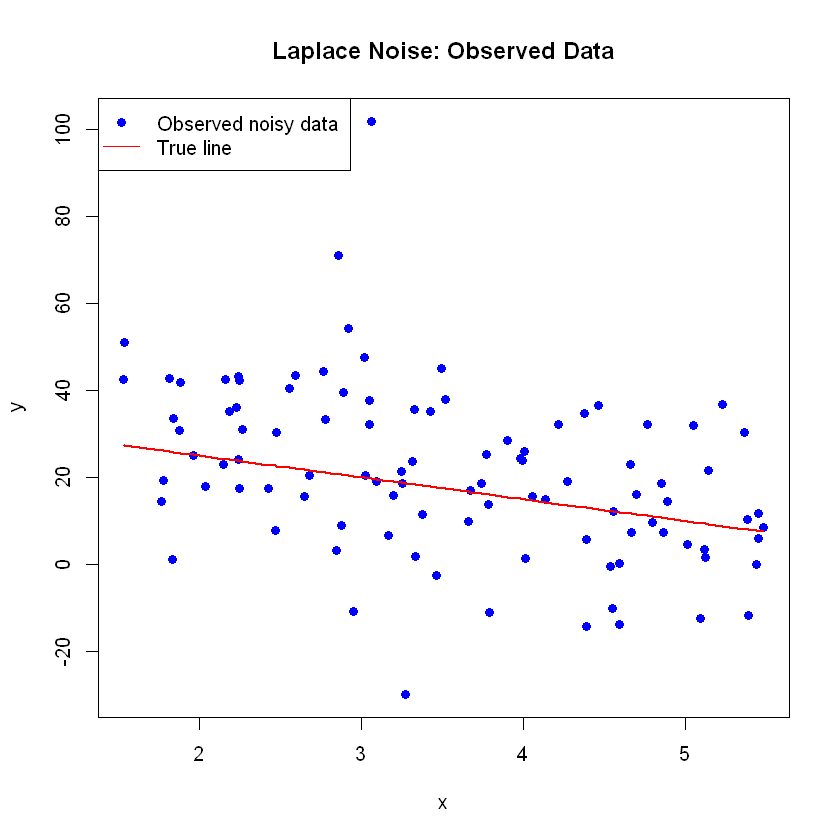

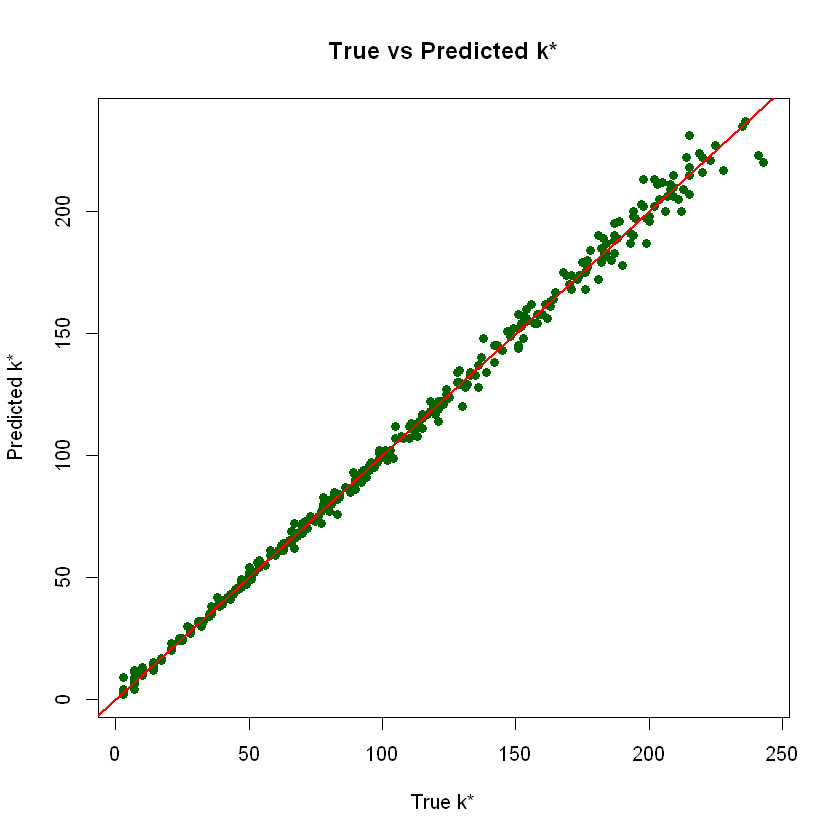

In [5]:
# ============================================================
# FULL R CODE
# Linear model with Laplace noise L(0, yi)
# Includes plots:
# 1. Observed noisy data vs true line
# 2. True k* vs predicted k*
# ============================================================

set.seed(42)

# ------------------------------------------------
# Package
# ------------------------------------------------
if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

# ------------------------------------------------
# Laplace random generator
# ------------------------------------------------
rlaplace <- function(n, location = 0, scale = 1) {
  if (length(scale) == 1) {
    scale <- rep(scale, n)
  }

  u <- runif(n, -0.5, 0.5)
  location - scale * sign(u) * log(1 - 2 * abs(u))
}

# ------------------------------------------------
# Simulate linear data with Laplace noise L(0, yi)
# ------------------------------------------------
simulate_linear_laplace_yi <- function(
    n = 100,
    w_true = -5,
    b_true = 35,
    x_min = 1.5,
    x_max = 5.5,
    min_scale = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  X <- runif(n, x_min, x_max)

  y_true <- w_true * X + b_true

  scale_i <- pmax(abs(y_true), min_scale)

  eps <- rlaplace(
    n = n,
    location = 0,
    scale = scale_i
  )

  Y <- y_true + eps

  data.frame(
    x = X,
    y = Y,
    y_true = y_true,
    scale_i = scale_i
  )
}

# ------------------------------------------------
# Safe helper
# ------------------------------------------------
safe_sd <- function(x) {
  if (length(x) <= 1) return(0)

  s <- sd(x)

  if (is.na(s) || is.nan(s) || is.infinite(s)) {
    return(0)
  }

  s
}

# ------------------------------------------------
# Standardization
# ------------------------------------------------
standardize_xy <- function(x, y, x_mean, x_sd, y_mean, y_sd) {
  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  xs <- (x - x_mean) / x_sd
  ys <- (y - y_mean) / y_sd

  list(X = xs, Y = ys)
}

# ------------------------------------------------
# Gradients
# ------------------------------------------------
grads <- function(X, Y, w, b) {
  r <- Y - (w * X + b)

  n <- length(X)

  dw <- (-2 / n) * sum(X * r)
  db <- (-2 / n) * sum(r)

  c(dw = dw, db = db)
}

step_gd <- function(X, Y, w, b, eta) {
  g <- grads(X, Y, w, b)

  c(
    w = as.numeric(w - eta * g["dw"]),
    b = as.numeric(b - eta * g["db"])
  )
}

step_ga <- function(X, Y, w, b, eta) {
  g <- grads(X, Y, w, b)

  c(
    w = as.numeric(w + eta * g["dw"]),
    b = as.numeric(b + eta * g["db"])
  )
}

fit_gd <- function(X, Y, iters = 800, eta = 0.10, w0 = 0, b0 = 0) {
  w <- as.numeric(w0)
  b <- as.numeric(b0)

  for (i in 1:iters) {
    p <- step_gd(X, Y, w, b, eta)

    w <- p["w"]
    b <- p["b"]
  }

  c(w = as.numeric(w), b = as.numeric(b))
}

# ------------------------------------------------
# One deletion experiment
# ------------------------------------------------
one_experiment_deleted_retained <- function(
    df,
    p_del,
    T_GD = 800,
    ETA_GD = 0.10,
    T_GA = 800,
    ETA_GA = 0.0015
) {
  x <- df$x
  y <- df$y

  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  x_mean <- mean(x)
  x_sd <- safe_sd(x)

  y_mean <- mean(y)
  y_sd <- safe_sd(y)

  st <- standardize_xy(
    x, y,
    x_mean, x_sd,
    y_mean, y_sd
  )

  X <- st$X
  Y <- st$Y

  full_fit <- fit_gd(
    X, Y,
    iters = T_GD,
    eta = ETA_GD
  )

  w_f <- full_fit["w"]
  b_f <- full_fit["b"]

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  X_del <- X[del_mask]
  Y_del <- Y[del_mask]

  X_ret <- X[!del_mask]
  Y_ret <- Y[!del_mask]

  ret_fit <- fit_gd(
    X_ret,
    Y_ret,
    iters = T_GD,
    eta = ETA_GD
  )

  w_r <- ret_fit["w"]
  b_r <- ret_fit["b"]

  w_ga <- w_f
  b_ga <- b_f

  traj_w <- c(w_ga)
  traj_b <- c(b_ga)

  for (i in 1:T_GA) {
    p <- step_ga(
      X_del,
      Y_del,
      w_ga,
      b_ga,
      ETA_GA
    )

    w_ga <- p["w"]
    b_ga <- p["b"]

    traj_w <- c(traj_w, w_ga)
    traj_b <- c(traj_b, b_ga)
  }

  dists <- (traj_w - w_r)^2 + (traj_b - b_r)^2

  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(
    df[del_mask, c("x", "y")]
  )

  retained_points <- as.matrix(
    df[!del_mask, c("x", "y")]
  )

  deleted_points <- deleted_points[
    order(deleted_points[, 1]),
    ,
    drop = FALSE
  ]

  retained_points <- retained_points[
    order(retained_points[, 1]),
    ,
    drop = FALSE
  ]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del
  )
}

# ------------------------------------------------
# Build many experiments
# ------------------------------------------------
build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 800,
    ETA_GD = 0.10,
    T_GA = 800,
    ETA_GA = 0.0015
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(
      1,
      min = p_min,
      max = p_max
    )

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      T_GD = T_GD,
      ETA_GD = ETA_GD,
      T_GA = T_GA,
      ETA_GA = ETA_GA
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

# ------------------------------------------------
# Embedding + pooling
# ------------------------------------------------
embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) {
    stop("Empty set encountered.")
  }

  embedded <- sweep(
    points_mat %*% W,
    2,
    b,
    "+"
  )

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(
    mean_pool,
    max_pool,
    min_pool,
    sd_pool
  )
}

# ------------------------------------------------
# Build pooled feature table
# ------------------------------------------------
build_pooled_feature_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(
      s$deleted_points,
      W,
      b
    )

    ret_vec <- embed_and_pool(
      s$retained_points,
      W,
      b
    )

    row_i <- as.data.frame(
      as.list(c(del_vec, ret_vec))
    )

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_",  1:embed_dim),
      paste0("del_min_emb_",  1:embed_dim),
      paste0("del_sd_emb_",   1:embed_dim),

      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_",  1:embed_dim),
      paste0("ret_min_emb_",  1:embed_dim),
      paste0("ret_sd_emb_",   1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  out <- do.call(rbind, rows)

  out <- na.omit(out)

  out
}

# ------------------------------------------------
# Scale features
# ------------------------------------------------
scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)

  sds <- sapply(df_features, safe_sd)

  sds[sds == 0] <- 1

  scaled <- as.data.frame(
    scale(
      df_features,
      center = means,
      scale = sds
    )
  )

  scaled[is.na(scaled)] <- 0

  list(
    data = scaled,
    means = means,
    sds = sds
  )
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(
    scale(
      df_features,
      center = means,
      scale = sds
    )
  )

  scaled[is.na(scaled)] <- 0

  scaled
}

# ------------------------------------------------
# Best nnet fit
# ------------------------------------------------
fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 6,
    decay = 0.001,
    maxit = 1000,
    maxnwts = 15000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) {
      next
    }

    pred_train <- as.numeric(
      predict(fit_try, x_train_sc)
    )

    sse <- sum(
      (pred_train - y_train)^2
    )

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) {
    stop("All nnet fits failed.")
  }

  best_fit
}

# ------------------------------------------------
# Postprocess predictions
# ------------------------------------------------
postprocess_khat <- function(
    pred_scaled,
    target_mean,
    target_sd,
    T_GA
) {
  pred_raw <- pred_scaled * target_sd + target_mean

  pred_int <- round(pred_raw)

  pred_int <- pmax(
    0,
    pmin(T_GA, pred_int)
  )

  list(
    pred_raw = pred_raw,
    pred_int = pred_int
  )
}

# ------------------------------------------------
# Cross-validation
# ------------------------------------------------
cv_mlp_regression <- function(
    meta_train,
    k_folds = 5,
    hidden_units = 6,
    decay = 0.001,
    maxit = 1000,
    n_repeats = 5,
    T_GA = 800,
    seed = 42
) {
  set.seed(seed)

  n <- nrow(meta_train)

  fold_id <- sample(
    rep(1:k_folds, length.out = n)
  )

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(
    names(meta_train),
    "target_k_star"
  )

  for (fold in 1:k_folds) {
    train_fold <- meta_train[
      fold_id != fold,
    ]

    valid_fold <- meta_train[
      fold_id == fold,
    ]

    x_train <- train_fold[
      ,
      feature_names,
      drop = FALSE
    ]

    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[
      ,
      feature_names,
      drop = FALSE
    ]

    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)

    y_sd_fold <- safe_sd(y_train_raw)

    if (y_sd_fold == 0) {
      y_sd_fold <- 1
    }

    y_train <- (
      y_train_raw - y_mean_fold
    ) / y_sd_fold

    sc <- scale_features_train(x_train)

    x_train_sc <- as.matrix(sc$data)

    x_valid_sc <- as.matrix(
      scale_features_apply(
        x_valid,
        sc$means,
        sc$sds
      )
    )

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      decay = decay,
      maxit = maxit,
      n_repeats = n_repeats,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(
      predict(mlp_fit, x_valid_sc)
    )

    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(
      mean(
        (pred_out$pred_raw - y_valid)^2
      )
    )

    rmse_int <- sqrt(
      mean(
        (pred_out$pred_int - y_valid)^2
      )
    )

    rmse_raw_vec <- c(
      rmse_raw_vec,
      rmse_raw
    )

    rmse_int_vec <- c(
      rmse_int_vec,
      rmse_int
    )
  }

  list(
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

# ------------------------------------------------
# Final train/test
# ------------------------------------------------
train_and_test_mlp <- function(
    meta_train,
    meta_test,
    hidden_units = 6,
    decay = 0.001,
    maxit = 1000,
    n_repeats = 5,
    T_GA = 800,
    seed = 42
) {
  feature_names <- setdiff(
    names(meta_train),
    "target_k_star"
  )

  target_mean <- mean(
    meta_train$target_k_star
  )

  target_sd <- safe_sd(
    meta_train$target_k_star
  )

  if (target_sd == 0) {
    target_sd <- 1
  }

  x_train <- meta_train[
    ,
    feature_names,
    drop = FALSE
  ]

  x_test <- meta_test[
    ,
    feature_names,
    drop = FALSE
  ]

  y_train_scaled <- (
    meta_train$target_k_star - target_mean
  ) / target_sd

  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc$data)

  x_test_sc <- as.matrix(
    scale_features_apply(
      x_test,
      sc$means,
      sc$sds
    )
  )

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    decay = decay,
    maxit = maxit,
    n_repeats = n_repeats,
    seed = seed
  )

  pred_scaled <- as.numeric(
    predict(final_mlp, x_test_sc)
  )

  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(
    mean(
      (pred_out$pred_raw - y_test)^2
    )
  )

  rmse_int <- sqrt(
    mean(
      (pred_out$pred_int - y_test)^2
    )
  )

  mae_int <- mean(
    abs(pred_out$pred_int - y_test)
  )

  list(
    y_test = y_test,
    pred_raw = pred_out$pred_raw,
    pred_int = pred_out$pred_int,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# ------------------------------------------------
# MAIN
# ------------------------------------------------
base_df <- simulate_linear_laplace_yi(
  n = 100,
  seed = 7
)

cat("Noise version: Laplace L(0, yi)\n")
cat("Total raw points:", nrow(base_df), "\n\n")

# ------------------------------------------------
# Plot 1: observed noisy data vs true line
# ------------------------------------------------
plot(
  base_df$x,
  base_df$y,
  pch = 16,
  col = "blue",
  main = "Laplace Noise: Observed Data",
  xlab = "x",
  ylab = "y"
)

ord <- order(base_df$x)

lines(
  base_df$x[ord],
  base_df$y_true[ord],
  col = "red",
  lwd = 2
)

legend(
  "topleft",
  legend = c("Observed noisy data", "True line"),
  col = c("blue", "red"),
  pch = c(16, NA),
  lty = c(NA, 1)
)

# ------------------------------------------------
# Build experiments
# ------------------------------------------------
samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 800,
  ETA_GD = 0.10,
  T_GA = 800,
  ETA_GA = 0.0015
)

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test  <- meta_all[-idx_meta_train, ]

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  hidden_units = 6
)

cat("Mean CV RMSE raw:",
    cv_res$mean_rmse_raw, "\n")

cat("Mean CV RMSE int:",
    cv_res$mean_rmse_int, "\n\n")

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 6
)

cat("Final Test RMSE raw:",
    final_res$rmse_raw, "\n")

cat("Final Test RMSE int:",
    final_res$rmse_int, "\n")

cat("Final Test MAE int:",
    final_res$mae_int, "\n")

# ------------------------------------------------
# Plot 2: true k* vs predicted k*
# ------------------------------------------------
plot(
  final_res$y_test,
  final_res$pred_int,
  pch = 16,
  col = "darkgreen",
  xlab = "True k*",
  ylab = "Predicted k*",
  main = "True vs Predicted k*"
)

abline(0, 1, col = "red", lwd = 2)